# Explore $H_2$ vs. $H_4$

In [1]:
# imports

from importlib import reload

import numpy as np
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from datetime import datetime, time
import random 

import pandas
import seaborn as sns

from oceancolor.tara import io as tara_io
from oceancolor.ph import pigments
from oceancolor.ph import absorption
from oceancolor.hydrolight import loisel23

from cnmf.oceanography import iops
from cnmf import zhu_nmf as nmf
from cnmf import io as cnmf_io

In [2]:
%matplotlib ipympl

# Load NMF

## Tara

In [5]:
dataset = 'Tara'
N_NMF, iop = 4, 'a'
d = cnmf_io.load_nmf(dataset, N_NMF, iop)
M = d['M']
coeff = d['coeff']
NMF_wave = d['wave']

Loading: /home/xavier/Projects/Oceanography/python/cnmf/cnmf/data/Tara/Tara_NMF_04_a.npz


In [6]:
coeff.shape

(239880, 4)

# Set a minimum value

In [19]:
coeff[:,1] = np.maximum(coeff[:,1], 1e-2)
coeff[:,3] = np.maximum(coeff[:,3], 1e-2)

# Generate a line by hand

In [32]:
xval = np.linspace(0.02, 20., 10000)
yval = 0.6*xval**0.75 

# Plot em

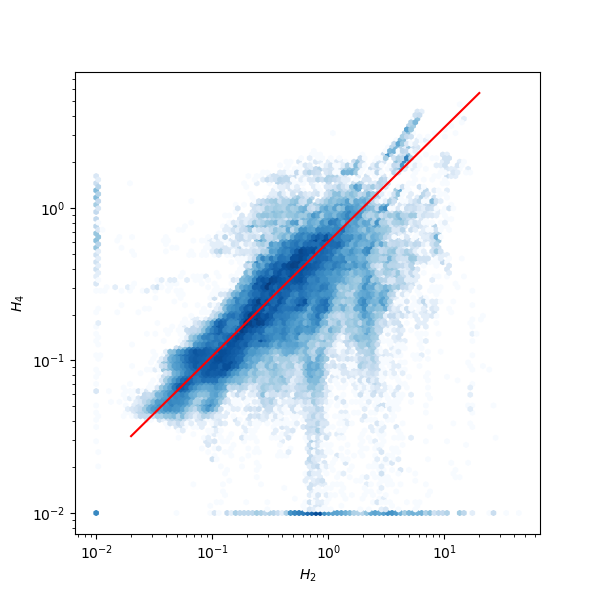

In [34]:
#
fig = plt.figure(figsize=(6,6))

plt.clf()
ax = plt.gca()
ax.hexbin(coeff[:,1], coeff[:,3], bins='log', 
                   xscale='log', yscale='log',
                    cmap='Blues')
#
ax.set_xlabel(r'$H_2$')
ax.set_ylabel(r'$H_4$')
#
#ax.plot([0.1, 3], [0.1, 3], 'r--')
ax.plot(xval, yval, 'r-')
#ax.legend()
#
plt.show()